# Capstone Project 1: Analysis of Adult Body Measurements (NHANES 2017–March 2020)

**Topic:** Working with `numpy` matrices (multidimensional data)

---

## Executive Summary

This report analyses two excerpts of the U.S. National Health and Nutrition Examination Survey (NHANES), containing seven body measurements for adult males and females. The principal findings are:

- Adult weight is **right-skewed** in both sexes. Males are heavier on average (mean ≈ 88.4 kg vs. 77.4 kg), whereas the *spread* of weights is almost identical (standard deviation ≈ 21.5 kg).
- Female BMI is strongly correlated with weight, hip and waist circumference (r ≈ 0.95), but essentially **uncorrelated with height** (r ≈ 0.03), as BMI is designed to be.
- Roughly **85% of females and 82% of males** exceed the commonly cited waist-to-height threshold of 0.5.
- The extreme BMI cases are driven chiefly by weight and circumference measurements rather than by height.

## Contents

1. Setup and Data Acquisition
2. Histograms of Body Weight
3. Box Plot of Body Weight
4. Numerical Summaries of Body Weight
5. BMI and Standardisation (Females)
6. Pairplot and Correlation Analysis
7. Waist-to-Height and Waist-to-Hip Ratios
8. Box Plot of the Ratios
9. Advantages and Disadvantages of BMI, WHtR and WHR
10. Extreme BMI Cases
11. Conclusions

## 1. Setup and Data Acquisition

The following cell imports the required libraries and downloads the two CSV files from the repository of Marek Gagolewski (if they are not already present locally). The files start with a block of comment lines (`#`) followed by one header row, hence the first 19 lines are skipped when reading the numerical data into `numpy` matrices named `male` and `female`.

In [1]:
import os
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=3, suppress=True, linewidth=120)

BASE_URL = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"
FILES = ["nhanes_adult_male_bmx_2020.csv", "nhanes_adult_female_bmx_2020.csv"]

for fname in FILES:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(BASE_URL + fname, fname)

# 18 comment lines + 1 header row = 19 lines to skip
male = np.loadtxt("nhanes_adult_male_bmx_2020.csv", delimiter=",", skiprows=19)
female = np.loadtxt("nhanes_adult_female_bmx_2020.csv", delimiter=",", skiprows=19)

columns = ["weight", "height", "upper arm length", "upper leg length",
           "arm circumference", "hip circumference", "waist circumference"]

print("male  :", male.shape)
print("female:", female.shape)
print("Number of missing values:", np.isnan(male).sum() + np.isnan(female).sum())

male  : (4081, 7)
female: (4221, 7)
Number of missing values: 0


**Discussion.** The `male` matrix contains 4,081 participants and the `female` matrix contains 4,221 participants, each described by seven measurements. No missing values are present, so no imputation or filtering is required. The columns, in order, are: weight (kg), standing height, upper arm length, upper leg length, arm circumference, hip circumference and waist circumference (all in cm).

## 2. Histograms of Body Weight

The purpose of this section is to compare the distribution of weight in females (top panel) and males (bottom panel). Both panels share identical x-axis limits via `plt.xlim`, which is essential for a fair visual comparison. The limits of 30 kg and 210 kg were chosen because the smallest observed weight is 32.6 kg and the largest is 204.6 kg.

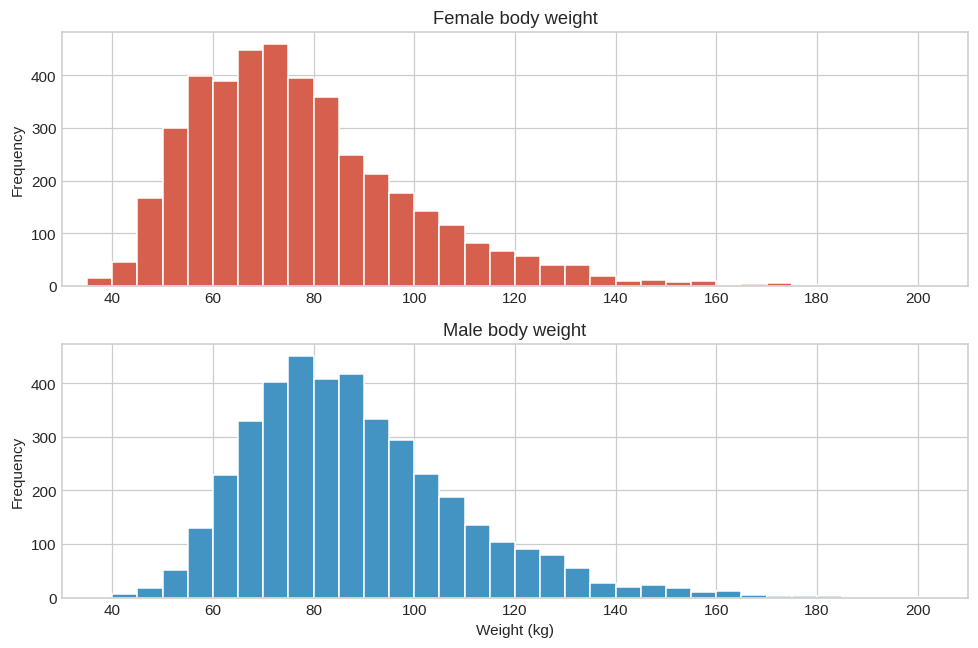

In [2]:
female_weights = female[:, 0]
male_weights = male[:, 0]
bins = np.arange(30, 211, 5)

plt.figure(figsize=(9, 6))

plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=bins, color="#d6604d", edgecolor="white")
plt.xlim(30, 210)
plt.title("Female body weight")
plt.ylabel("Frequency")

plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=bins, color="#4393c3", edgecolor="white")
plt.xlim(30, 210)
plt.title("Male body weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Discussion.** Both histograms are unimodal and visibly asymmetric: the bulk of the observations lies between roughly 50 and 110 kg, while a long tail extends towards high weights (right skew). The male distribution is shifted to the right relative to the female one, with its mode at a higher weight. Despite this shift, the two shapes are remarkably similar.

## 3. Box Plot of Body Weight

A box-and-whisker plot summarises each distribution by its median, quartiles and potential outliers, allowing a compact side-by-side comparison. The function receives a list of two vectors, `[female_weights, male_weights]`.

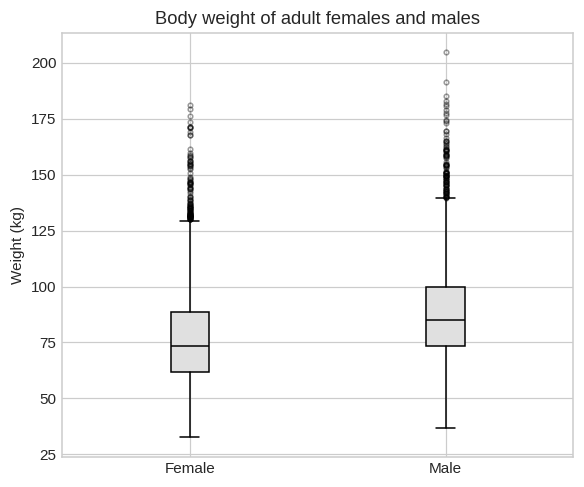

In [3]:
plt.figure(figsize=(6, 5))
plt.boxplot([female_weights, male_weights], tick_labels=["Female", "Male"], vert=True,
            patch_artist=True, boxprops=dict(facecolor="#e0e0e0"),
            medianprops=dict(color="black"), flierprops=dict(markersize=3, alpha=0.4))
plt.ylabel("Weight (kg)")
plt.title("Body weight of adult females and males")
plt.show()

**Discussion.** The median male weight (about 85 kg) is clearly above the median female weight (about 74 kg), and the entire box of the males is shifted upwards. The box heights (interquartile ranges) are nearly identical, indicating comparable variability in the central half of each group. In both groups, the upper whisker is followed by numerous outlying points, whereas the lower side has almost none, which confirms the right skewness already seen in the histograms. The most extreme observations belong to the males (just above 200 kg), yet the female group contains very heavy individuals as well (up to 180.9 kg).

## 4. Numerical Summaries of Body Weight

This section computes basic aggregates describing **location** (mean, median, quartiles), **dispersion** (standard deviation, interquartile range, range, coefficient of variation) and **shape** (skewness, excess kurtosis) of the weights. The sample standard deviation uses `ddof=1`.

In [4]:
def summarise(x):
    q1, med, q3 = np.quantile(x, [0.25, 0.5, 0.75])
    return {
        "n": len(x),
        "mean": np.mean(x), "median": med, "Q1": q1, "Q3": q3,
        "min": np.min(x), "max": np.max(x),
        "std. deviation": np.std(x, ddof=1), "IQR": q3 - q1,
        "range": np.ptp(x),
        "coeff. of variation": np.std(x, ddof=1) / np.mean(x),
        "skewness": scipy.stats.skew(x),
        "excess kurtosis": scipy.stats.kurtosis(x),
    }

summary = pd.DataFrame({"Female": summarise(female_weights),
                        "Male": summarise(male_weights)})
summary.round(3)

,Female,Male
n,4221.000,4081.000
mean,77.404,88.365
median,73.600,85.000
Q1,61.600,73.300
Q3,88.700,99.800
min,32.600,36.800
max,180.900,204.600
std. deviation,21.545,21.422
IQR,27.100,26.500
range,148.300,167.800


**Discussion.**

- **Location:** The mean weight of males (88.4 kg) exceeds that of females (77.4 kg) by roughly 11 kg; the medians (85.0 kg vs. 73.6 kg) differ by a similar margin. In both groups the mean is larger than the median, which is typical for right-skewed data.
- **Dispersion:** The standard deviations (21.5 kg for females, 21.4 kg for males) and the interquartile ranges (27.1 kg vs. 26.5 kg) are practically the same in absolute terms. Relative to the mean, however, females are more dispersed (coefficient of variation 0.28 vs. 0.24).
- **Shape:** Both skewness coefficients are positive and close to 1 (1.03 for females, 0.98 for males), confirming moderate right skew. The positive excess kurtosis (≈ 1.4–1.5) indicates heavier tails than the normal distribution.

In summary, the two distributions are similar in shape and spread, but the male distribution is displaced towards higher values.

## 5. BMI and Standardisation (Females)

### 5.1 Adding the Body Mass Index

The body mass index is defined as

$$\text{BMI} = \frac{\text{weight (kg)}}{\text{height (m)}^2}.$$

Since height is stored in centimetres, it is divided by 100 first. The result is appended as an eighth column to the `female` matrix.

In [5]:
bmi = female[:, 0] / (female[:, 1] / 100) ** 2
female = np.column_stack((female, bmi))
columns_f = columns + ["BMI"]

print("New shape of the female matrix:", female.shape)
print("Mean BMI  : %.2f" % bmi.mean())
print("Median BMI: %.2f" % np.median(bmi))
print("Underweight (<18.5)    : %.1f%%" % (100 * np.mean(bmi < 18.5)))
print("Normal (18.5-24.9)     : %.1f%%" % (100 * np.mean((bmi >= 18.5) & (bmi < 25))))
print("Overweight (25-29.9)   : %.1f%%" % (100 * np.mean((bmi >= 25) & (bmi < 30))))
print("Obese (>=30)           : %.1f%%" % (100 * np.mean(bmi >= 30)))

New shape of the female matrix: (4221, 8)
Mean BMI  : 30.10
Median BMI: 28.89
Underweight (<18.5)    : 2.0%
Normal (18.5-24.9)     : 25.9%
Overweight (25-29.9)   : 27.9%
Obese (>=30)           : 44.2%


**Discussion.** The median female BMI is about 28.9 and the mean is about 30.1, which is in the overweight-to-obese range of the WHO classification. Only 2.0% of the women are underweight and roughly 26% have a BMI in the normal range, while about 28% are overweight and 44% are obese. This reflects the high prevalence of excess weight in the U.S. adult population.

### 5.2 Standardised Matrix

Each column is converted to z-scores, $z = (x - \bar{x}) / s$, giving it zero mean and unit standard deviation. This puts all variables on a comparable, unit-free scale.

In [6]:
zfemale = (female - female.mean(axis=0)) / female.std(axis=0, ddof=1)

print("Column means:", zfemale.mean(axis=0))
print("Column std. :", zfemale.std(axis=0, ddof=1))

Column means: [ 0.  0. -0. -0.  0. -0.  0. -0.]
Column std. : [1. 1. 1. 1. 1. 1. 1. 1.]


**Discussion.** The column means are zero (up to floating-point error) and the standard deviations equal one, so the standardisation was carried out correctly. The matrix `zfemale` is used in the next sections.

## 6. Pairplot and Correlation Analysis

A scatterplot matrix of the standardised height, weight, waist circumference, hip circumference and BMI (taken from `zfemale`) is drawn first. Subsequently, Pearson's correlation coefficient (linear association) and Spearman's rank correlation coefficient (monotonic association, robust to outliers) are computed for all pairs.

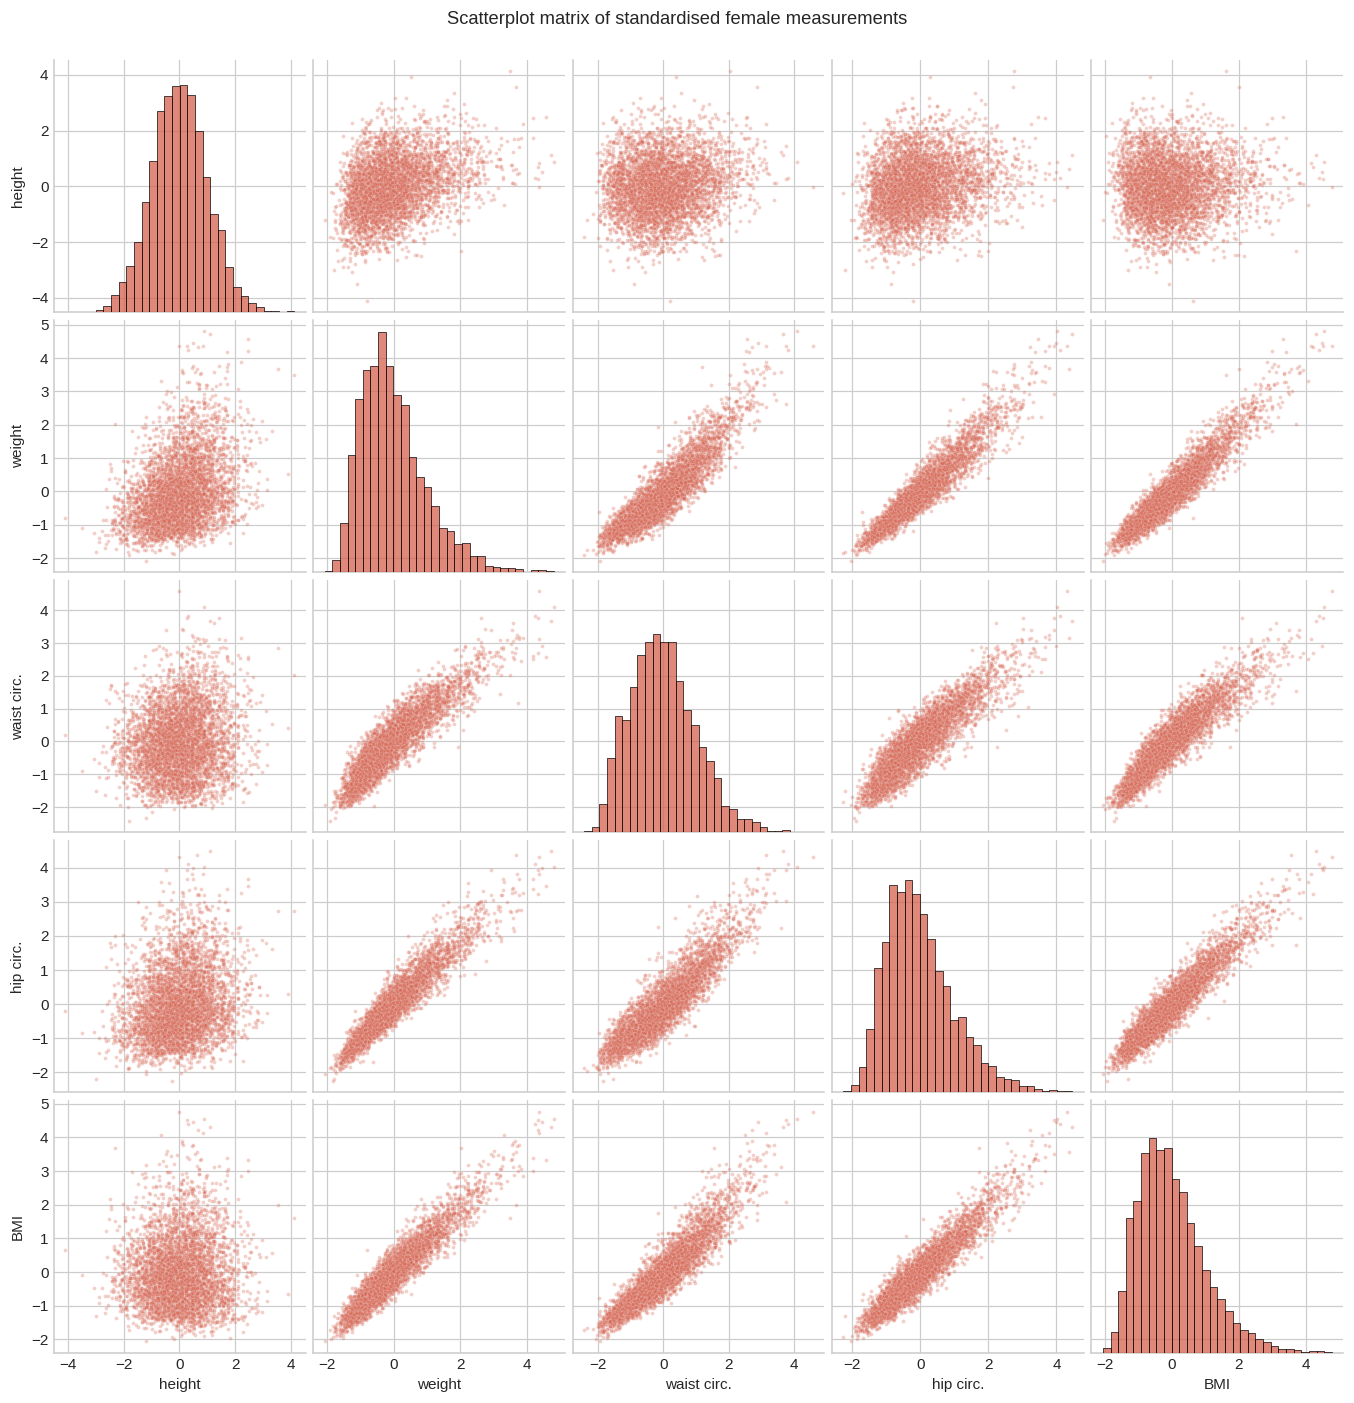

In [7]:
selected = [1, 0, 6, 5, 7]  # height, weight, waist, hip, BMI
names = ["height", "weight", "waist circ.", "hip circ.", "BMI"]
zdf = pd.DataFrame(zfemale[:, selected], columns=names)

g = sns.pairplot(zdf, corner=False, plot_kws=dict(s=6, alpha=0.3, color="#d6604d"),
                 diag_kws=dict(color="#d6604d", bins=30))
g.figure.suptitle("Scatterplot matrix of standardised female measurements", y=1.02)
plt.show()

In [8]:
pearson = pd.DataFrame(np.corrcoef(zfemale[:, selected], rowvar=False), index=names, columns=names)
spearman = pd.DataFrame(scipy.stats.spearmanr(zfemale[:, selected]).statistic, index=names, columns=names)

print("Pearson correlation coefficients")
display(pearson.round(3))
print("Spearman correlation coefficients")
display(spearman.round(3))

Pearson correlation coefficients


,height,weight,waist circ.,hip circ.,BMI
height,1.000,0.345,0.127,0.203,0.033
weight,0.345,1.000,0.905,0.947,0.946
waist circ.,0.127,0.905,1.000,0.897,0.921
hip circ.,0.203,0.947,0.897,1.000,0.944
BMI,0.033,0.946,0.921,0.944,1.000


Spearman correlation coefficients


,height,weight,waist circ.,hip circ.,BMI
height,1.000,0.339,0.109,0.205,0.020
weight,0.339,1.000,0.900,0.947,0.938
waist circ.,0.109,0.900,1.000,0.888,0.923
hip circ.,0.205,0.947,0.888,1.000,0.934
BMI,0.020,0.938,0.923,0.934,1.000


**Discussion.**

- **Strong positive relationships:** Weight, waist circumference, hip circumference and BMI are all very strongly correlated with one another (Pearson r between 0.90 and 0.95). The scatterplots show elongated, nearly linear clouds. Weight and BMI (0.946), weight and hip circumference (0.947) and hip circumference and BMI (0.944) are particularly tight.
- **Height is the exception:** Height has only a weak correlation with weight (0.35) and with hip (0.20) and waist circumference (0.13), and is practically uncorrelated with BMI (0.03). This is expected because BMI normalises weight by the square of height, thereby removing most of the height effect.
- **Pearson vs. Spearman:** The two coefficients differ by at most about 0.02 for every pair, which means that the relationships are essentially monotonic and linear, and that the outliers do not distort the Pearson results noticeably.
- **Caution:** A high correlation reflects association only; it does not imply causation. Furthermore, weight and BMI are partly related by construction, so their high correlation is partly mathematical.

## 7. Waist-to-Height and Waist-to-Hip Ratios

Two additional central-adiposity indicators are computed for both sexes and appended as new columns:

- **Waist-to-height ratio (WHtR)** = waist circumference / standing height,
- **Waist-to-hip ratio (WHR)** = waist circumference / hip circumference.

For the `female` matrix, which already has BMI in column 7, the ratios become columns 8 and 9; for the `male` matrix they become columns 7 and 8.

In [9]:
# female: columns -> 0..6 measurements, 7 = BMI
female = np.column_stack((female, female[:, 6] / female[:, 1], female[:, 6] / female[:, 5]))
# male: columns -> 0..6 measurements
male = np.column_stack((male, male[:, 6] / male[:, 1], male[:, 6] / male[:, 5]))

whtr_f, whr_f = female[:, 8], female[:, 9]
whtr_m, whr_m = male[:, 7], male[:, 8]

ratios = pd.DataFrame({
    "WHtR female": [whtr_f.mean(), np.median(whtr_f), whtr_f.std(ddof=1), np.mean(whtr_f > 0.5)],
    "WHtR male":   [whtr_m.mean(), np.median(whtr_m), whtr_m.std(ddof=1), np.mean(whtr_m > 0.5)],
    "WHR female":  [whr_f.mean(), np.median(whr_f), whr_f.std(ddof=1), np.mean(whr_f > 0.85)],
    "WHR male":    [whr_m.mean(), np.median(whr_m), whr_m.std(ddof=1), np.mean(whr_m > 0.90)],
}, index=["mean", "median", "std. deviation", "share above threshold"])
print("Thresholds: WHtR > 0.5 (both sexes); WHR > 0.85 (females) and > 0.90 (males)")
ratios.round(3)

Thresholds: WHtR > 0.5 (both sexes); WHR > 0.85 (females) and > 0.90 (males)


,WHtR female,WHtR male,WHR female,WHR male
mean,0.616,0.586,0.900,0.971
median,0.610,0.582,0.903,0.977
std. deviation,0.108,0.094,0.072,0.077
share above threshold,0.846,0.817,0.752,0.805


**Discussion.** The median WHtR is about 0.61 for females and 0.58 for males, and both are above the frequently cited cut-off of 0.5 (84.6% of females and 81.7% of males exceed it). The WHR behaves differently: males have a higher median (≈ 0.98) than females (≈ 0.90), because women typically carry proportionally more circumference at the hips. Using the WHO-style cut-offs of 0.85 (females) and 0.90 (males), around 75% of females and 81% of males are above the threshold.

## 8. Box Plot of the Ratios

The four distributions (WHtR for females and males, WHR for females and males) are shown side by side in one box-and-whisker plot.

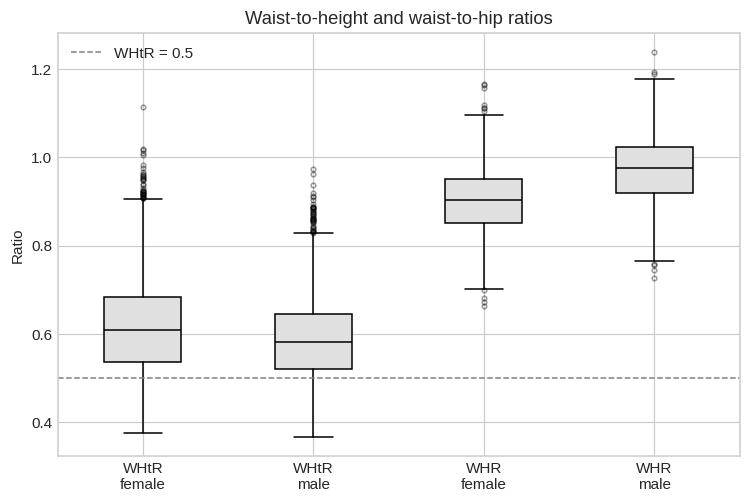

In [10]:
plt.figure(figsize=(8, 5))
plt.boxplot([whtr_f, whtr_m, whr_f, whr_m],
            tick_labels=["WHtR\nfemale", "WHtR\nmale", "WHR\nfemale", "WHR\nmale"],
            patch_artist=True, medianprops=dict(color="black"),
            flierprops=dict(markersize=3, alpha=0.4),
            boxprops=dict(facecolor="#e0e0e0"))
plt.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="WHtR = 0.5")
plt.ylabel("Ratio")
plt.title("Waist-to-height and waist-to-hip ratios")
plt.legend()
plt.show()

**Discussion.** The two ratios occupy different ranges, so the comparison should be made *within* each pair. For WHtR the female box lies above the male box and is wider, i.e. women show higher and somewhat more variable values (standard deviation 0.108 vs. 0.094). The reverse holds for WHR, where the male box is higher (median ≈ 0.98 vs. 0.90) and the spreads are similar (0.072 vs. 0.077). Hence the two indices rank the sexes differently: WHtR flags women as having relatively more abdominal girth, while WHR flags men, a difference largely explained by sex-specific body fat distribution. All four distributions exhibit outliers, mainly on the upper side.

## 9. Advantages and Disadvantages of BMI, WHtR and WHR

| Index | Advantages | Disadvantages |
|---|---|---|
| **BMI** | Very simple; needs only weight and height; widely used, with standard categories enabling international comparison; strongly associated with weight-related health risk at population level. | Does not distinguish fat from muscle or bone mass, so muscular persons may be misclassified as overweight; ignores fat distribution; thresholds may not be equally valid across ethnicity, age and sex; weak for individual diagnosis. |
| **Waist-to-height ratio (WHtR)** | Captures abdominal (central) fat, which is more closely linked to cardiometabolic risk; a single boundary (0.5) works for both sexes and many age groups; easy to explain ("keep your waist below half your height"). | Waist measurement is sensitive to technique, posture and time of day; does not separate subcutaneous from visceral fat; less established in clinical guidelines than BMI. |
| **Waist-to-hip ratio (WHR)** | Reflects fat distribution (android vs. gynoid pattern); informative about cardiovascular risk independently of overall weight. | Requires two measurements, which doubles the measurement error; the ratio can remain unchanged when both waist and hip grow, hiding weight gain; sex-specific thresholds are needed; hip circumference is hard to interpret on its own. |

**Overall,** no single index is sufficient. BMI is convenient for screening large populations, WHtR adds information on central adiposity, and WHR helps characterise fat distribution. They are best used in combination and alongside clinical assessment.

## 10. Extreme BMI Cases

To understand what the tails of the BMI distribution look like, the five females with the **lowest** and the five with the **highest** BMI are selected using `numpy.argsort`. Their standardised measurements (rows of `zfemale`) are printed; the final column shows the standardised BMI. Positive values indicate measurements above the average of the sample, negative values below.

In [11]:
order = np.argsort(female[:, 7])
lowest, highest = order[:5], order[-5:]

header = ["weight", "height", "arm len.", "leg len.", "arm circ.", "hip circ.", "waist", "BMI"]
print("Raw BMI of the 5 lowest :", female[lowest, 7].round(1))
print("Raw BMI of the 5 highest:", female[highest, 7].round(1))

print("\nStandardised measurements - 5 LOWEST BMI")
display(pd.DataFrame(zfemale[lowest], columns=header).round(2))
print("Standardised measurements - 5 HIGHEST BMI")
display(pd.DataFrame(zfemale[highest], columns=header).round(2))

Raw BMI of the 5 lowest : [14.2 14.6 14.8 15.  15.4]
Raw BMI of the 5 highest: [64.2 64.7 65.1 65.3 67. ]

Standardised measurements - 5 LOWEST BMI


,weight,height,arm len.,leg len.,arm circ.,hip circ.,waist,BMI
0,-2.08,-1.22,-1.55,-1.17,-2.19,-2.04,-1.94,-2.05
1,-1.88,-0.19,-1.72,0.39,-2.44,-1.85,-2.06,-1.99
2,-1.54,1.81,0.63,0.57,-2.27,-1.68,-1.71,-1.97
3,-1.84,-0.26,-0.23,0.51,-2.30,-2.25,-1.86,-1.94
4,-1.61,0.89,-0.10,0.48,-2.21,-1.83,-1.71,-1.89


Standardised measurements - 5 HIGHEST BMI


,weight,height,arm len.,leg len.,arm circ.,hip circ.,waist,BMI
0,4.25,0.29,1.86,-0.98,2.37,4.10,3.82,4.40
1,4.46,0.50,1.69,-1.14,3.35,3.98,2.90,4.46
2,4.35,0.28,2.84,1.94,4.37,3.92,3.75,4.51
3,4.80,0.89,2.12,1.82,3.78,4.02,4.08,4.54
4,4.36,-0.03,-0.06,-0.17,2.78,4.32,4.57,4.76


**Discussion.**

- **Lowest BMI (≈ 14.2–15.4):** These women are severely underweight by WHO standards. Their weight z-scores are approximately −1.5 to −2.1, and their arm, hip and waist circumferences are about two standard deviations below the mean. Heights vary from slightly below to well above average (z from −1.2 to +1.8), i.e. a low BMI here stems from low body mass and small circumferences, not from short stature.
- **Highest BMI (≈ 64–67):** These cases are extreme (BMI above 40 is classified as class III obesity). Weight z-scores lie between about 4.3 and 4.8, with hip and waist circumferences 3 to 4.6 standard deviations above the mean, while height is average (z between −0.03 and 0.9). The extreme BMI is therefore a consequence of weight, not of height.
- The magnitude is asymmetric: the lowest cases are about 2 standard deviations below the mean, whereas the highest are more than 4 above, again reflecting the right-skewed distributions. Such values should be verified for plausibility, but they are consistent with the physical measurements in all other columns, which suggests genuine rather than erroneous records.

## 11. Conclusions

1. **Weight:** Males are about 11 kg heavier on average, but the absolute dispersion and the right-skewed shape are very similar in both sexes.
2. **BMI and correlations:** Weight, hip and waist circumference and BMI are strongly and almost linearly associated (r ≈ 0.90–0.95), while height is nearly independent of BMI.
3. **Central adiposity:** More than four fifths of the participants exceed the WHtR cut-off of 0.5. Females have a higher WHtR and males a higher WHR, so the choice of index influences conclusions about differences between the sexes.
4. **Extremes:** The most extreme BMI values are explained by body mass and girth, not height.
5. **Recommendation:** Several complementary indices should be used for any health-related interpretation, and the data should be seen as population-level, cross-sectional evidence only; no causal statements can be derived from it.

*Data source: U.S. Centers for Disease Control and Prevention, National Health and Nutrition Examination Survey, 2017–March 2020 (as prepared by M. Gagolewski).*